In [1]:
import hvplot.xarray
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime
from pathlib import Path

In [2]:
### PARAMETERS

target_reference_level = 2000

missing_values_in_target = True


using_missing_indices = True
using_transport_from_previous_year = True
use_deep_dvdz = False


add_tmp = False
add_sal = False


random_split_data = False

assert target_reference_level in [2000, 4800], "Only 2000 and 4800 are supported as reference levels"
version = 'v3'
n_compartments = 17
n_embedding = 16

distance_assignment_module  = 'distance'

experiment_path = Path(f'../rapid-geostrophic-reconstruction/figs/experiment_{datetime.now().strftime("%Y%m%d_%H%M%S")}')
dataset_path = Path('../rapid-geostrophic-reconstruction/datasets/smoothing_90_days/argo_after_2012/base_sample/')

ref_folder = f'{abs(target_reference_level)}m_ref'

assert version in ['v2', 'v3']
assert distance_assignment_module in ['distance', 'fixed']

In [3]:
def load_merged_argo_dataset_and_tumo_obs(time_smoothing, lat_bounds = None):
    ds_argo_merged = xr.open_dataset(dataset_path / f'../../ds_argo_obs.nc')
    t_umo_obs = xr.open_dataset(dataset_path / ref_folder/ f't_umo_obs.nc')

    t_umo_obs = t_umo_obs.resample(time = time_smoothing).mean()

    ds_argo_merged = ds_argo_merged.sel(time = t_umo_obs.time.data)#, method = 'nearest')
    ds_argo_merged = ds_argo_merged.isel(z = slice(None, None, -1))

    if lat_bounds is not None:
        ds_argo_merged = ds_argo_merged.where((ds_argo_merged.lat >= lat_bounds[0]) & (ds_argo_merged.lat <= lat_bounds[1]))

    return ds_argo_merged, t_umo_obs


def load_merged_argo_dataset_and_tumo(time_smoothing, lat_bounds = None, suffix = None):
    ds_argo_merged = xr.open_dataset(dataset_path / f'ds_argo_viking_KFS003-{suffix}.nc')
    t_umo_obs = xr.open_dataset(dataset_path / ref_folder / f't_umo_sim{"_miss" if missing_values_in_target else ""}_KFS003-{suffix}.nc')

    ds_pos = xr.open_dataset(dataset_path / ref_folder/ f'ds_pos_sim{"_miss" if missing_values_in_target else ""}_KFS003-{suffix}.nc')
    dv_dz = xr.open_dataset(dataset_path / ref_folder / f'dv_dz_sim{"_miss" if missing_values_in_target else ""}_fillup_KFS003-{suffix}.nc')


    # t_umo_obs['time'] = t_umo_obs.time.dt.floor('D')
    # t_umo_obs = t_umo_obs.resample(time = time_smoothing).mean()

    t_umo_obs = t_umo_obs.groupby(t_umo_obs.time.dt.floor(time_smoothing)).mean().rename({'floor': 'time'})
    ds_pos = ds_pos.groupby(ds_pos.time.dt.floor(time_smoothing)).mean().rename({'floor': 'time'})
    dv_dz = dv_dz.groupby(dv_dz.time.dt.floor(time_smoothing)).mean().rename({'floor': 'time'})

    t_umo_obs = t_umo_obs.sel(time = slice(ds_argo_merged.time.min(), ds_argo_merged.time.max()))
    ds_pos = ds_pos.sel(time = slice(ds_argo_merged.time.min(), ds_argo_merged.time.max()))
    dv_dz = dv_dz.sel(time = slice(ds_argo_merged.time.min(), ds_argo_merged.time.max()))

    ds_argo_merged = ds_argo_merged.sel(time = t_umo_obs.time.data)
    ds_argo_merged = ds_argo_merged.isel(z = slice(None, None, -1))

    if lat_bounds is not None:
        ds_argo_merged = ds_argo_merged.where((ds_argo_merged.lat >= lat_bounds[0]) & (ds_argo_merged.lat <= lat_bounds[1]))

    return ds_argo_merged, t_umo_obs, ds_pos, dv_dz

In [4]:
# Load the argo_dataset and the ground truth dataset
time_smoothing = '90D'

lat_bounds = (25, 27)


# ds_argo_merged, t_umo_obs = load_merged_argo_dataset_and_tumo(time_smoothing)#, lat_bounds = lat_bounds)

def load_merged_argo_dataset_and_tumo_cycles(suffixe, time_smoothing):
    ds_argo_merged = None
    t_umo_obs = None
    ds_pos_sim = None
    dv_dz_obs = None
    
    assert len(suffixe) == 2, 'Longer? Think on the t_delta '

    for suffix in suffixe:
        ds_argo_merged_cycle, t_umo_obs_cycle, ds_pos_cycle, dv_dz_cycle = load_merged_argo_dataset_and_tumo(time_smoothing, suffix= suffix)

        if ds_argo_merged is None:
            ds_argo_merged = ds_argo_merged_cycle
            t_umo_obs = t_umo_obs_cycle
            ds_pos_sim = ds_pos_cycle
            dv_dz_obs = dv_dz_cycle
        else:
            t_delta = ds_argo_merged.time.max() - ds_argo_merged_cycle.time.min() + pd.Timedelta(time_smoothing)
            ds_argo_merged_cycle['time'] = ds_argo_merged_cycle['time'] + t_delta 
            t_umo_obs_cycle['time'] = t_umo_obs_cycle['time'] + t_delta
            ds_pos_cycle['time'] = ds_pos_cycle['time'] + t_delta
            dv_dz_cycle['time'] = dv_dz_cycle['time'] + t_delta
            ds_argo_merged_cycle['time_1d'] = ds_argo_merged_cycle['time_1d'] + t_delta

            ds_argo_merged = xr.concat([ds_argo_merged, ds_argo_merged_cycle], dim = 'time')
            t_umo_obs = xr.concat([t_umo_obs, t_umo_obs_cycle], dim = 'time')

            ds_pos_sim = xr.concat([ds_pos_sim, ds_pos_cycle], dim = 'time')
            dv_dz_obs = xr.concat([dv_dz_obs, dv_dz_cycle], dim = 'time')

    return ds_argo_merged, t_umo_obs, ds_pos_sim, dv_dz_obs, t_delta

suffixe = ['1st_70None', '2nd_NoneNone']
ds_argo_merged, t_umo_obs, ds_pos_sim, dv_dz_obs, t_delta = load_merged_argo_dataset_and_tumo_cycles(suffixe, time_smoothing)

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


## Single Profile Processing

We will load the ds_argo_merged dataset as thre base where each prfoile in the ten day window is present.
THen we will create 4 embedding one for each of the moorings and each profile is assigned by distance to those emebeddings. 
Each profile will create based on the currtent state and its rho values a delta that will be added to the embedding.

In [5]:
from copy import deepcopy

In [6]:
ds_argo_merged_10days, t_umo_10days, ds_pos_sim, dv_dz_obs, t_delta = load_merged_argo_dataset_and_tumo_cycles(['1st_70None', '2nd_NoneNone'], '90D')

compartments = [
    ['west_p', -76.74, -70, 'west'],
    ['mar_west_p', -60, -47, 'east'],
    ['mar_east_p', -47, -40, 'west'],
    ['east_p', -30, -13.5, 'east']
]

# VIKING contains more detailed information in the upper layers as the Argo dataset
# Argo only measures each 20 meters while VIKING has measurments at 0, 3, 9, 12 ... meters

boundaries = np.arange(-10000, 1, 20) + 10
depth_grouped = ds_argo_merged_10days.groupby_bins('z', boundaries).mean()
depth_grouped = depth_grouped.where(ds_argo_merged_10days.z.groupby_bins('z', boundaries).count() > 0)


ds_argo_merged_10days = depth_grouped.assign_coords(z_bins = ('z_bins', np.arange(-10000, 1, 20)[1:])).rename({'z_bins': 'z'}).sel(z = ds_argo_merged_10days.z, method = 'nearest').assign_coords(z = ds_argo_merged_10days.z).transpose('time', 'pos', 'z')

# We only take the first 2000 meters depth
ds_argo_merged_10days = ds_argo_merged_10days.where(ds_argo_merged_10days.z > -2000, drop = True)

ds_argo_merged_10days = ds_argo_merged_10days.where(ds_argo_merged_10days.salinity > 0)
# ds_argo_merged_10days = ds_argo_merged_10days.where((ds_argo_merged_10days.z <= -1500) | (ds_argo_merged_10days.z > -100) , drop = True)
# ds_argo_merged_10days = ds_argo_merged_10days.where((ds_argo_merged_10days.z <= -1500) , drop = True)

ds_argo_merged_10days = ds_argo_merged_10days.sortby('z')

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


In [7]:
ds_argo_merged_10days

<xarray.Dataset>
Dimensions:       (time: 488, pos: 691, z: 29)
Coordinates:
  * pos           (pos) int64 0 1 2 3 4 5 6 7 ... 684 685 686 687 688 689 690
  * time          (time) datetime64[ns] 1970-01-01 1970-04-01 ... 2090-01-01
  * z             (z) float32 -1.85e+03 -1.655e+03 -1.471e+03 ... -9.454 -3.047
    lon           (time, pos) float32 -26.8 -40.85 -39.25 -18.0 ... nan nan nan
    lat           (time, pos) float32 28.02 26.64 27.53 29.33 ... nan nan nan
    time_1d       (time, pos) datetime64[ns] 1969-11-17T12:00:00 ... NaT
    pressure      (z) float32 1.85e+03 1.655e+03 1.471e+03 ... 16.36 9.454 3.047
Data variables:
    temperature   (time, pos, z) float32 4.445 5.031 5.623 6.113 ... nan nan nan
    salinity      (time, pos, z) float32 35.13 35.18 35.22 35.22 ... nan nan nan
    profile_mask  (time, pos, z) float64 1.0 1.0 1.0 1.0 1.0 ... nan nan nan nan
    ct            (time, pos, z) float64 4.44 5.025 5.615 6.105 ... nan nan nan
    rho           (time, pos, z) float64 1.036e+03 1.035e+03 ... nan nan

In [8]:
dv_dz_obs

<xarray.Dataset>
Dimensions:        (z: 242, time: 488)
Coordinates:
  * z              (z) float64 -4.82e+03 -4.8e+03 -4.78e+03 ... -40.0 -20.0 -0.0
  * time           (time) datetime64[ns] 1970-01-01 1970-04-01 ... 2090-01-01
Data variables:
    dv_dz_times_X  (time, z) float64 -4.571 -4.529 -4.487 ... -230.5 -246.4

In [9]:
load_std = True

# Prepare a dataset by 1) splitting the data, 2) scaling the input data 
train_slice_pos = 'start'

train_ratio = .6
val_ratio = .15


# t_umo_10days = t_umo_10days.sel(time = slice(None, '2020-01-01'))
# ds_argo_merged_10days = ds_argo_merged_10days.sel(time = slice(None, '2020-01-01'))





if random_split_data:

    indices = np.arange(t_umo_10days.time.shape[0])
    np.random.shuffle(indices)

    if train_slice_pos == 'start':
        train_indices = indices[:int(train_ratio * indices.shape[0])]
        val_indices = indices[int(train_ratio * indices.shape[0]):int((train_ratio + val_ratio) * indices.shape[0])]
        test_indices = indices[int((train_ratio + val_ratio) * indices.shape[0]):]
    elif train_slice_pos == 'end':
        train_indices = indices[-int(train_ratio * indices.shape[0]):]
        val_indices = indices[-int((train_ratio + val_ratio) * indices.shape[0]): -int(train_ratio * indices.shape[0])]
        test_indices = indices[:-int((train_ratio + val_ratio) * indices.shape[0])]
else:
    test_indices = t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2005-01-01', '2022-01-01')).ti.values
    # test_indices = t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2055-01-01', None)).ti.values
    valid_indices_1 =  t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('1995-01-01', '2005-01-01')).ti.values
    valid_indices_2 =  t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2025-01-01','2035-01-01')).ti.values
    val_indices = np.concatenate([valid_indices_1, valid_indices_2])
    # val_indices =  t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2035-01-01', '2055-01-01')).ti.values


    # test_indices = t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2010-01-01', '2023-08-01')).ti.values
    # valid_indices_1 =  t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2000-01-01', '2010-01-01')).ti.values
    # valid_indices_2 =  t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2025-01-01','2035-01-01')).ti.values
    # val_indices = np.concatenate([valid_indices_1, valid_indices_2])





    train_mask = ~np.isin(np.arange(t_umo_10days.time.shape[0]), np.concatenate((val_indices, test_indices)))
    train_indices = np.arange(t_umo_10days.time.shape[0])[train_mask]




rho_mean = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).isel(time = train_indices).mean(['time', 'pos']).rho
temperature_mean = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).isel(time = train_indices).mean(['time', 'pos']).temperature
salinity_mean = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).isel(time = train_indices).mean(['time', 'pos']).salinity

if load_std:
    temperature_std = xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_temperature_std_argo.nc').temperature
    salinity_std = xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_salinity_std_argo.nc').salinity
    rho_std = xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_rho_std_argo.nc').rho
    std_transport = xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_transport_std_argo.nc').dv_dz_times_X
else:
    rho_std = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).isel(time = train_indices).std(['time', 'pos']).rho
    temperature_std = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).isel(time = train_indices).std(['time', 'pos']).temperature
    salinity_std = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).isel(time = train_indices).std(['time', 'pos']).salinity
    std_transport = t_umo_10days.isel(time = train_indices).std('time').dv_dz_times_X




def standardize_rho(ds_pos, rho_mean=None, rho_std=None):
    ds_pos = deepcopy(ds_pos)
    ds_pos["rho"] = (ds_pos["rho"] - rho_mean) / rho_std
    return ds_pos

def standardize_temperature(ds_pos, temperature_mean=None, temperature_std=None):
    ds_pos = deepcopy(ds_pos)
    ds_pos["temperature"] = (ds_pos["temperature"] - temperature_mean) / temperature_std
    return ds_pos

def standardize_salinity(ds_pos, salinity_mean=None, salinity_std=None):
    ds_pos = deepcopy(ds_pos)
    ds_pos["salinity"] = (ds_pos["salinity"] - salinity_mean) / salinity_std
    return ds_pos


ds_argo_merged_10days_std = standardize_rho(
    ds_argo_merged_10days,
    rho_mean=rho_mean, 
    rho_std=rho_std,
)

ds_argo_merged_10days_std = standardize_temperature(
    ds_argo_merged_10days_std,
    temperature_mean=temperature_mean,
    temperature_std=temperature_std,
)

ds_argo_merged_10days_std = standardize_salinity(
    ds_argo_merged_10days_std,
    salinity_mean=salinity_mean,
    salinity_std=salinity_std,
)

ds_argo_merged_10days_std = ds_argo_merged_10days_std.fillna(0)

feature_list = [ds_argo_merged_10days_std.rho]

if add_tmp:
    feature_list.append(ds_argo_merged_10days_std.temperature)
if add_sal:
    feature_list.append(ds_argo_merged_10days_std.salinity)

nn_feature_ds = xr.concat(
    feature_list, dim = 'feature'
).stack(nn_feature = ['feature', 'z'])
train_X_scaled = nn_feature_ds.isel(time = train_indices).values
val_X_scaled = nn_feature_ds.isel(time = val_indices).values
test_X_scaled = nn_feature_ds.isel(time = test_indices).values


train_X_mask = ds_argo_merged_10days.isel(time = train_indices).profile_mask.fillna(0).astype(bool).values
val_X_mask = ds_argo_merged_10days.isel(time = val_indices).profile_mask.fillna(0).astype(bool).values
test_X_mask = ds_argo_merged_10days.isel(time = test_indices).profile_mask.fillna(0).astype(bool).values

train_X_lon = ds_argo_merged_10days.isel(time = train_indices).lon.values
val_X_lon = ds_argo_merged_10days.isel(time = val_indices).lon.values
test_X_lon = ds_argo_merged_10days.isel(time = test_indices).lon.values

offset_days = (
    (
        ds_argo_merged_10days.time_1d -
        ds_argo_merged_10days.time
    )
    .fillna(0).dt.days 
)

train_X_days = offset_days.isel(time = train_indices).values
val_X_days = offset_days.isel(time = val_indices).values
test_X_days = offset_days.isel(time = test_indices).values

train_y = t_umo_10days.isel(time = train_indices).dv_dz_times_X
val_y = t_umo_10days.isel(time = val_indices).dv_dz_times_X
test_y = t_umo_10days.isel(time = test_indices).dv_dz_times_X

train_y_prev = t_umo_10days.isel(
    time = xr.DataArray(train_indices.reshape(-1, 1) - (np.arange(3) + 1).reshape(1,-1))
).dv_dz_times_X.values
val_y_prev = t_umo_10days.isel(
    time = xr.DataArray(val_indices.reshape(-1, 1) - (np.arange(3) + 1).reshape(1,-1))
).dv_dz_times_X.values
test_y_prev = t_umo_10days.isel(
    time = xr.DataArray(test_indices.reshape(-1, 1) - (np.arange(3) + 1).reshape(1,-1))
).dv_dz_times_X.values

# train_y_prev = dv_dz_obs.where(dv_dz_obs.z > -2000, drop = True).isel(
#     time = xr.DataArray(train_indices.reshape(-1, 1) - (np.arange(2) + 1).reshape(1,-1))
# ).dv_dz_times_X.values.reshape(train_indices.shape[0], -1)
# val_y_prev = dv_dz_obs.where(dv_dz_obs.z > -2000, drop = True).isel(
#     time = xr.DataArray(val_indices.reshape(-1, 1) - (np.arange(2) + 1).reshape(1,-1))
# ).dv_dz_times_X.values.reshape(val_indices.shape[0], -1)
# test_y_prev = dv_dz_obs.where(dv_dz_obs.z > -2000, drop = True).isel(
#     time = xr.DataArray(test_indices.reshape(-1, 1) - (np.arange(2) + 1).reshape(1,-1))
# ).dv_dz_times_X.values.reshape(test_indices.shape[0], -1)


mean_transport  = train_y.mean('time')

train_y_scaled = (train_y - mean_transport) / std_transport
val_y_scaled = (val_y - mean_transport) / std_transport
test_y_scaled = (test_y - mean_transport) / std_transport

train_y_prev_scaled = (train_y_prev - mean_transport.values) / std_transport.values
val_y_prev_scaled = (val_y_prev - mean_transport.values) / std_transport.values
test_y_prev_scaled = (test_y_prev - mean_transport.values) / std_transport.values

train_y_scaled = train_y_scaled.fillna(0).values
val_y_scaled = val_y_scaled.fillna(0).values
test_y_scaled = test_y_scaled.fillna(0).values

# train_y_prev_scaled = train_y_prev_scaled.fillna(0).values
# val_y_prev_scaled = val_y_prev_scaled.fillna(0).values
# test_y_prev_scaled = test_y_prev_scaled.fillna(0).values

# dv_dz_obs = xr.open_dataset('../rapid-geostrophic-reconstruction/data/dv_dz_sim_miss_70None.nc')
# dv_dz_obs = dv_dz_obs.resample(time = time_smoothing).mean()
dv_dz_moorings = dv_dz_obs.sel(time = ds_argo_merged_10days.time).where(dv_dz_obs.z <= -2000, drop = True)

mean_dv_dz_moorings = dv_dz_moorings.isel(time = train_indices).mean(['time']).dv_dz_times_X
std_dv_dz_moorings = dv_dz_moorings.isel(time = train_indices).std(['time']).dv_dz_times_X

train_dv_dz_moorings_scaled = ((dv_dz_moorings.isel(time = train_indices).dv_dz_times_X - mean_dv_dz_moorings) / std_dv_dz_moorings).fillna(0).values
val_dv_dz_moorings_scaled = ((dv_dz_moorings.isel(time = val_indices).dv_dz_times_X - mean_dv_dz_moorings) / std_dv_dz_moorings).fillna(0).values
test_dv_dz_moorings_scaled = ((dv_dz_moorings.isel(time = test_indices).dv_dz_times_X - mean_dv_dz_moorings) / std_dv_dz_moorings).fillna(0).values

if missing_values_in_target:
    scaled_mis_positions = ds_pos_sim.sel(time = ds_argo_merged_10days.time, method='nearest').missing_indices / 10

    train_missing_indices = scaled_mis_positions.isel(time = train_indices).values
    val_missing_indices = scaled_mis_positions.isel(time = val_indices).values
    test_missing_indices = scaled_mis_positions.isel(time = test_indices).values

else:
    train_missing_indices = np.zeros((train_indices.shape[0], 4))
    val_missing_indices = np.zeros((val_indices.shape[0], 4))
    test_missing_indices = np.zeros((test_indices.shape[0], 4))


In [10]:
from torch.utils.data import DataLoader, TensorDataset, Dataset
class ProfileDataset(Dataset):
    def __init__(self, X, y, y_prev, mask, lon, dv_dz, days, compartments, missing_indices):
        self.X = X
        self.y = y
        self.y_prev = y_prev
        self.mask = mask
        self.lon = lon
        self.days = days
        self.compartment = compartments 
        self.dv_dz = dv_dz
        self.missing_indices = missing_indices

        self.len_compartments = len(compartments)

        self.X_per_compartment = []
        self.lon_per_compartment = []
        self.dv_dz_per_compartment = []
        self.days_per_compartment = []
        self.missing_indices_per_compartment = []

        self.min_longitude = min([comp[1] for comp in compartments])
        self.max_longitude = max([comp[2] for comp in compartments])



        self.lon_scaled = (self.lon - self.min_longitude) / (self.max_longitude - self.min_longitude)

        self.days_scaled = self.days / (pd.Timedelta(time_smoothing).days / 2)
        
        for i in range(len(self)):
            mask = self.mask[i]


            compartment_X_per_sample = []
            compartment_lon_per_sample = []
            compartment_days_per_sample = []

            for j in range(self.len_compartments):

                # get all profile indices that are in the compartment and in the mask 
                profile_indices = np.where((self.lon[i] > self.compartment[j][1]) & (self.lon[i] < self.compartment[j][2]) & mask.any(axis = -1))[0]

                if len(profile_indices) < 1:
                    compartment_X_per_sample.append(np.empty(0))
                    compartment_lon_per_sample.append(np.empty(0))
                    compartment_days_per_sample.append(np.empty(0))
                    continue

                lon_compartments = self.lon_scaled[i][profile_indices]
                sorted_indices_longitude = lon_compartments.argsort()


                # If I have the sequence -5, -15, 5 the argsort will return [1, 0, 2]
                # As we want to have those profiles as last that are closes to the mooring due to the vanishing gradient 
                # For West moorings the smallest value has to be the last one
                if self.compartment[j][3] == 'west':
                    sorted_indices_longitude = sorted_indices_longitude[::-1]
                
                profile_indices = profile_indices[sorted_indices_longitude]

                compartment_X_per_sample.append(self.X[i][ profile_indices])
                compartment_lon_per_sample.append(self.lon_scaled[i][profile_indices])
                compartment_days_per_sample.append(self.days_scaled[i][profile_indices])
            

            self.X_per_compartment.append(compartment_X_per_sample)
            self.lon_per_compartment.append(compartment_lon_per_sample)
            self.dv_dz_per_compartment.append(self.dv_dz[i])
            self.missing_indices_per_compartment.append(self.missing_indices[i])
            self.days_per_compartment.append(compartment_days_per_sample)


    def __len__(self):
        return self.X.shape[0] 

    def __getitem__(self, idx):

        if using_transport_from_previous_year:
            y_prev = self.y_prev[idx]
        else:
            y_prev = np.zeros_like(self.y_prev[idx])

        if using_missing_indices:
            missing_indices_per_compartment = self.missing_indices_per_compartment[idx] 
        else:
            missing_indices_per_compartment = np.zeros_like(self.missing_indices_per_compartment[idx])
        
        if use_deep_dvdz:
            dv_dz = self.dv_dz_per_compartment[idx]
        else:
            dv_dz = np.zeros_like(self.dv_dz_per_compartment[idx])



        return self.X_per_compartment[idx], self.y[idx], y_prev, self.lon_per_compartment[idx], dv_dz, self.days_per_compartment[idx], missing_indices_per_compartment

In [11]:
import torch
train_dataset = ProfileDataset(train_X_scaled, train_y, train_y_prev_scaled, train_X_mask, train_X_lon, train_dv_dz_moorings_scaled, train_X_days, compartments, train_missing_indices)
val_dataset = ProfileDataset(val_X_scaled, val_y, val_y_prev_scaled, val_X_mask, val_X_lon, val_dv_dz_moorings_scaled, val_X_days, compartments, val_missing_indices)
test_dataset = ProfileDataset(test_X_scaled, test_y, test_y_prev_scaled, test_X_mask, test_X_lon, test_dv_dz_moorings_scaled, test_X_days, compartments, test_missing_indices)
    

def merge_profiles(data):
    """
        X: is a list and each entry is a list of compartments in which the profiles are stored with variable length
    """
    X, y, y_prev, lon, dv_dz, days, missing_indices = zip(*data)
    X = [[torch.tensor(x_compartment).float() for x_compartment in x_sample] for x_sample in X]
    y = torch.tensor(np.array(y)).float()
    y_prev = torch.tensor(np.array(y_prev)).float()
    lon = [[torch.tensor(lon_compartment).float() for lon_compartment in lon_sample] for lon_sample in lon]
    dv_dz = [torch.tensor(dv_dz_sample).float() for dv_dz_sample in dv_dz]
    missing_indices = [torch.tensor(missing_indices_sample).float() for missing_indices_sample in missing_indices]
    days = [[torch.tensor(days_compartment).float() for days_compartment in day_sample] for day_sample in days]

    

    return X, y, y_prev, lon, dv_dz, days,missing_indices

dl = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=merge_profiles, num_workers=4)
val_dl = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=merge_profiles, num_workers=4)
test_dl = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=merge_profiles, num_workers=4)


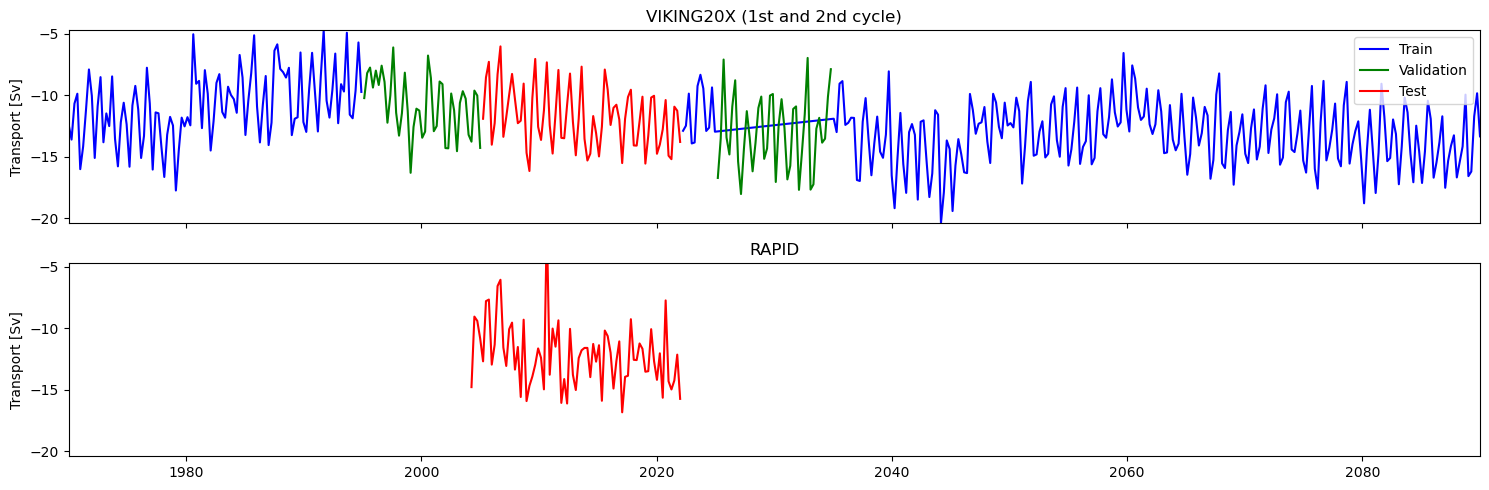

In [12]:
import matplotlib.pyplot as plt

ds_argo_merged_obs, t_umo_obs_obs = load_merged_argo_dataset_and_tumo_obs(time_smoothing)#, lat_bounds = lat_bounds)


fig = plt.figure(figsize=(15,5))
ax = fig.add_subplot(2,1,1)

train1 = t_umo_10days.isel(time = train_indices[train_indices <= 101]).dv_dz_times_X
ax.plot(train1.time, train1.values, c = 'b', label = 'Train')
train2 = t_umo_10days.isel(time = train_indices[train_indices > 101]).dv_dz_times_X
ax.plot(train2.time, train2.values, c = 'b')


val1 = t_umo_10days.isel(time = val_indices[val_indices < 150]).dv_dz_times_X
val2 = t_umo_10days.isel(time = val_indices[val_indices > 150]).dv_dz_times_X

ax.plot(val1.time, val1.values, c = 'g', label ='Validation')
ax.plot(val2.time, val2.values, c = 'g')

test = t_umo_10days.isel(time = test_indices).dv_dz_times_X
ax.plot(test.time, test.values, c = 'r', label = 'Test')

ax.set_xlim(t_umo_10days.time.min().data, t_umo_10days.time.max().data)
ax.set_ylim(t_umo_10days.dv_dz_times_X.min().data, t_umo_10days.dv_dz_times_X.max().data)
ax.set_xticklabels([])
ax.set_title('VIKING20X (1st and 2nd cycle)')
ax.set_ylabel('Transport [Sv]')
plt.legend()
ax = fig.add_subplot(2,1,2)
ax.set_xlim(t_umo_10days.time.min().data, t_umo_10days.time.max().data)
ax.set_ylim(t_umo_10days.dv_dz_times_X.min().data, t_umo_10days.dv_dz_times_X.max().data)

ax.set_title('RAPID')
ax.plot(t_umo_obs_obs.dv_dz_times_X.time, t_umo_obs_obs.dv_dz_times_X.values, c = 'r')
ax.set_ylabel('Transport [Sv]')
fig.tight_layout()
fig.savefig('../rapid-geostrophic-reconstruction/train_val_test_split.png')

## Models

### SUSTeR LIB

In [13]:
#Original SUSTeR
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as init
import math

class Align(nn.Module):
    def __init__(self, c_in, c_out):
        super(Align, self).__init__()
        self.c_in = c_in
        self.c_out = c_out
        self.align_conv = nn.Conv2d(
            in_channels=c_in, out_channels=c_out, kernel_size=(1, 1))

    def forward(self, x):
        if self.c_in > self.c_out:
            x = self.align_conv(x)
        elif self.c_in < self.c_out:
            batch_size, _, timestep, n_vertex = x.shape
            x = torch.cat([x, torch.zeros(
                [batch_size, self.c_out - self.c_in, timestep, n_vertex]).to(x)], dim=1)
        else:
            x = x

        return x


class CausalConv1d(nn.Conv1d):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, enable_padding=False, dilation=1, groups=1, bias=True):
        if enable_padding == True:
            self.__padding = (kernel_size - 1) * dilation
        else:
            self.__padding = 0
        super(CausalConv1d, self).__init__(in_channels, out_channels, kernel_size=kernel_size,
                                           stride=stride, padding=self.__padding, dilation=dilation, groups=groups, bias=bias)

    def forward(self, input):
        result = super(CausalConv1d, self).forward(input)
        if self.__padding != 0:
            return result[:, :, : -self.__padding]

        return result


class CausalConv2d(nn.Conv2d):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, enable_padding=False, dilation=1, groups=1, bias=True):
        kernel_size = nn.modules.utils._pair(kernel_size)
        stride = nn.modules.utils._pair(stride)
        dilation = nn.modules.utils._pair(dilation)
        if enable_padding == True:
            self.__padding = [int((kernel_size[i] - 1) * dilation[i])
                              for i in range(len(kernel_size))]
        else:
            self.__padding = 0
        self.left_padding = nn.modules.utils._pair(self.__padding)
        super(CausalConv2d, self).__init__(in_channels, out_channels, kernel_size,
                                           stride=stride, padding=0, dilation=dilation, groups=groups, bias=bias)

    def forward(self, input):
        if self.__padding != 0:
            input = F.pad(
                input, (self.left_padding[1], 0, self.left_padding[0], 0))
        result = super(CausalConv2d, self).forward(input)

        return result


class TemporalConvLayer(nn.Module):

    # Temporal Convolution Layer (GLU)
    #
    #        |--------------------------------| * Residual Connection *
    #        |                                |
    #        |    |--->--- CasualConv2d ----- + -------|
    # -------|----|                                   ⊙ ------>
    #             |--->--- CasualConv2d --- Sigmoid ---|
    #

    # param x: tensor, [bs, c_in, ts, n_vertex]

    def __init__(self, Kt, c_in, c_out, n_vertex, act_func):
        super(TemporalConvLayer, self).__init__()
        self.Kt = Kt
        self.c_in = c_in
        self.c_out = c_out
        self.n_vertex = n_vertex
        self.align = Align(c_in, c_out)
        if act_func == 'glu' or act_func == 'gtu':
            self.causal_conv = CausalConv2d(
                in_channels=c_in, out_channels=2 * c_out, kernel_size=(Kt, 1), enable_padding=False, dilation=1)
        else:
            self.causal_conv = CausalConv2d(in_channels=c_in, out_channels=c_out, kernel_size=(
                Kt, 1), enable_padding=False, dilation=1)
        self.act_func = act_func
        self.sigmoid = nn.Sigmoid()
        self.tanh = nn.Tanh()
        self.relu = nn.ReLU()
        self.leaky_relu = nn.LeakyReLU()
        self.silu = nn.SiLU()

    def forward(self, x):
        x_in = self.align(x)[:, :, self.Kt - 1:, :]
        x_causal_conv = self.causal_conv(x)

        if self.act_func == 'glu' or self.act_func == 'gtu':
            x_p = x_causal_conv[:, : self.c_out, :, :]
            x_q = x_causal_conv[:, -self.c_out:, :, :]

            if self.act_func == 'glu':
                # GLU was first purposed in
                # *Language Modeling with Gated Convolutional Networks*.
                # URL: https://arxiv.org/abs/1612.08083
                # Input tensor X is split by a certain dimension into tensor X_a and X_b.
                # In the original paper, GLU is defined as Linear(X_a) ⊙ Sigmoid(Linear(X_b)).
                # However, in PyTorch, GLU is defined as X_a ⊙ Sigmoid(X_b).
                # URL: https://pytorch.org/docs/master/nn.functional.html#torch.nn.functional.glu
                # Because in original paper, the representation of GLU and GTU is ambiguous.
                # So, it is arguable which one version is correct.

                # (x_p + x_in) ⊙ Sigmoid(x_q)
                x = torch.mul((x_p + x_in), self.sigmoid(x_q))

            else:
                # Tanh(x_p + x_in) ⊙ Sigmoid(x_q)
                x = torch.mul(self.tanh(x_p + x_in), self.sigmoid(x_q))

        elif self.act_func == 'relu':
            x = self.relu(x_causal_conv + x_in)

        elif self.act_func == 'leaky_relu':
            x = self.leaky_relu(x_causal_conv + x_in)

        elif self.act_func == 'silu':
            x = self.silu(x_causal_conv + x_in)

        else:
            raise NotImplementedError(
                f'ERROR: The activation function {self.act_func} is not implemented.')

        return x


class ChebGraphConv(nn.Module):
    def __init__(self, c_in, c_out, Ks, bias):
        super(ChebGraphConv, self).__init__()
        self.c_in = c_in
        self.c_out = c_out
        self.Ks = Ks
        self.weight = nn.Parameter(torch.FloatTensor(Ks, c_in, c_out))
        if bias:
            self.bias = nn.Parameter(torch.FloatTensor(c_out))
        else:
            self.register_parameter('bias', None)
        self.reset_parameters()

    def reset_parameters(self):
        init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            fan_in, _ = init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
            init.uniform_(self.bias, -bound, bound)

    def forward(self, x, gso):
        #bs, c_in, ts, n_vertex = x.shape
        x = torch.permute(x, (0, 2, 3, 1))

        gso = gso.to(x.device)

        if self.Ks - 1 < 0:
            raise ValueError(
                f'ERROR: the graph convolution kernel size Ks has to be a positive integer, but received {self.Ks}.')
        elif self.Ks - 1 == 0:
            x_0 = x
            x_list = [x_0]
        elif self.Ks - 1 == 1:
            x_0 = x
            x_1 = torch.einsum('bhi,btij->bthj', gso, x)
            x_list = [x_0, x_1]
        elif self.Ks - 1 >= 2:
            x_0 = x
            x_1 = torch.einsum('bhi,btij->bthj', gso, x)
            x_list = [x_0, x_1]
            for k in range(2, self.Ks):
                x_list.append(torch.einsum('bhi,btij->bthj', 2 *
                              gso, x_list[k - 1]) - x_list[k - 2])

        x = torch.stack(x_list, dim=2)

        cheb_graph_conv = torch.einsum('btkhi,kij->bthj', x, self.weight)

        if self.bias is not None:
            cheb_graph_conv = torch.add(cheb_graph_conv, self.bias)
        else:
            cheb_graph_conv = cheb_graph_conv

        return cheb_graph_conv


class GraphConv(nn.Module):
    def __init__(self, c_in, c_out, bias):
        super(GraphConv, self).__init__()
        self.c_in = c_in
        self.c_out = c_out
        self.weight = nn.Parameter(torch.FloatTensor(c_in, c_out))
        if bias:
            self.bias = nn.Parameter(torch.FloatTensor(c_out))
        else:
            self.register_parameter('bias', None)
        self.reset_parameters()

    def reset_parameters(self):
        init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            fan_in, _ = init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
            init.uniform_(self.bias, -bound, bound)

    def forward(self, x, gso):
        #bs, c_in, ts, n_vertex = x.shape
        x = torch.permute(x, (0, 2, 3, 1))

        first_mul = torch.einsum('hi,btij->bthj', gso, x)
        second_mul = torch.einsum('bthi,ij->bthj', first_mul, self.weight)

        if self.bias is not None:
            graph_conv = torch.add(second_mul, self.bias)
        else:
            graph_conv = second_mul

        return graph_conv


class GraphConvLayer(nn.Module):
    def __init__(self, graph_conv_type, c_in, c_out, Ks, bias):
        super(GraphConvLayer, self).__init__()
        self.graph_conv_type = graph_conv_type
        self.c_in = c_in
        self.c_out = c_out
        self.align = Align(c_in, c_out)
        self.Ks = Ks
        if self.graph_conv_type == 'cheb_graph_conv':
            self.cheb_graph_conv = ChebGraphConv(c_out, c_out, Ks, bias)
        elif self.graph_conv_type == 'graph_conv':
            self.graph_conv = GraphConv(c_out, c_out, bias)

    def forward(self, x, gso):
        x_gc_in = self.align(x)
        if self.graph_conv_type == 'cheb_graph_conv':
            x_gc = self.cheb_graph_conv(x_gc_in, gso)
        elif self.graph_conv_type == 'graph_conv':
            x_gc = self.graph_conv(x_gc_in, gso)
        x_gc = x_gc.permute(0, 3, 1, 2)
        x_gc_out = torch.add(x_gc, x_gc_in)

        return x_gc_out


class STConvBlock(nn.Module):
    # STConv Block contains 'TGTND' structure
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # G: Graph Convolution Layer (ChebGraphConv or GraphConv)
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normolization
    # D: Dropout

    def __init__(self, Kt, Ks, n_vertex, last_block_channel, channels, act_func, graph_conv_type, bias, droprate):
        super(STConvBlock, self).__init__()
        self.tmp_conv1 = TemporalConvLayer(
            Kt, last_block_channel, channels[0], n_vertex, act_func)
        self.graph_conv = GraphConvLayer(
            graph_conv_type, channels[0], channels[1], Ks, bias)
        self.tmp_conv2 = TemporalConvLayer(
            Kt, channels[1], channels[2], n_vertex, act_func)
        self.tc2_ln = nn.LayerNorm([n_vertex, channels[2]])
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=droprate)

    def forward(self, x, gso):
        x = self.tmp_conv1(x)
        x = self.graph_conv(x, gso)
        x = self.relu(x)
        x = self.tmp_conv2(x)
        x = self.tc2_ln(x.permute(0, 2, 3, 1)).permute(0, 3, 1, 2)
        x = self.dropout(x)

        return x, gso


class OutputBlock(nn.Module):
    # Output block contains 'TNFF' structure
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normolization
    # F: Fully-Connected Layer
    # F: Fully-Connected Layer

    def __init__(self, Ko, last_block_channel, channels, end_channel, n_vertex, act_func, bias, droprate):
        super(OutputBlock, self).__init__()
        self.tmp_conv1 = TemporalConvLayer(
            Ko, last_block_channel, channels[0], n_vertex, act_func)
        self.fc1 = nn.Linear(
            in_features=channels[0], out_features=channels[1], bias=bias)
        self.fc2 = nn.Linear(
            in_features=channels[1], out_features=end_channel, bias=bias)
        self.tc1_ln = nn.LayerNorm([n_vertex, channels[0]])
        self.relu = nn.ReLU()
        self.leaky_relu = nn.LeakyReLU()
        self.silu = nn.SiLU()
        self.dropout = nn.Dropout(p=droprate)

    def forward(self, x):
        x = self.tmp_conv1(x)
        x = self.tc1_ln(x.permute(0, 2, 3, 1))
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x).permute(0, 3, 1, 2)

        return x


class ContextAwareMeanState(nn.Module):

    def __init__(self, n_proxy, n_embedding, n_context) -> None:
        super().__init__()

        self.n_proxy = n_proxy
        self.n_embedding = n_embedding

        self.fc1 = nn.Linear(n_context, n_embedding)
        self.fc2 = nn.Linear(n_embedding, n_proxy * n_embedding)


    def forward(self, context):

        global_embed = self.fc1(context)
        global_embed = F.relu(global_embed)

        Xbar = self.fc2(global_embed)

        return Xbar.reshape(-1, self.n_proxy, self.n_embedding)
    

class Embedding(nn.Module):

    def __init__(self, embed_dim, obs_dim, n_proxy) -> None:
        super().__init__()
        self.fc1_1 = nn.Linear(obs_dim + embed_dim * n_proxy, embed_dim)
        self.fc1_2 = nn.Linear(embed_dim , embed_dim)

        self.fc2_1 = nn.Linear(2, n_proxy)
        self.fc2_2 = nn.Linear(n_proxy, n_proxy)

        self.fc3_1 = nn.Linear(embed_dim, embed_dim)

        self.embed_dim = embed_dim
        self.n_proxy = n_proxy

    def forward(self, obs, v):
        
        ## Concat O and X for the embedding vector. 
        input = torch.concat((obs, v.reshape( -1).unsqueeze(dim = 0).expand(obs.shape[0], -1)), dim = -1)
        
        ## Create from the O and X the piece of information that should be incorporated into the network.
        x_emebdding = self.fc1_1(input)
        x_emebdding = F.relu(x_emebdding)
        x_emebdding = self.fc1_2(x_emebdding)
        x_emebdding = F.relu(x_emebdding)


        ## Use the position of the observations to find the best matching hidden node.
        positions = obs[..., :2]
        x_proxies = self.fc2_1(positions)
        x_proxies = F.relu(x_proxies)
        x_proxies = self.fc2_2(x_proxies)

        proxy_density = F.softmax(x_proxies, dim = -1) 

        ## Sample a single graph node from the created distributions and add the information to those nodes.
        sampled_proxy_index = torch.multinomial(proxy_density.reshape(-1, self.n_proxy), 1)
        mask = proxy_density#F.one_hot(sampled_proxy_index, num_classes = self.n_proxy).float().reshape(proxy_density.shape)
       
        obs_mask = torch.any(obs != 0, dim = -1).unsqueeze(dim=-1).expand(-1, self.n_proxy)
        mask = torch.mul(obs_mask, mask)

        new_information = self.fc3_1(x_emebdding)
        dotV_obs = torch.matmul(mask.unsqueeze(dim = -1), new_information.unsqueeze(dim = -2))

        return dotV_obs, mask

class SimpleOutput(nn.Module):

    def __init__(self, n_proxy, embed_dim, n_target) -> None:
        super().__init__()

        self.fc1 = nn.Linear(n_proxy * embed_dim, 256)
        self.fc2 = nn.Linear(256, 128)

        self.map = nn.Linear(128, n_target)

    def forward(self, VF, TP):

        x = self.fc1(VF)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        y = self.map(x)

        return y

class LocationBasedOutputv2(nn.Module):

    def __init__(self, n_proxy, embed_dim, targets) -> None:
        super().__init__()

        self.reduce = nn.Sequential(
            nn.Linear(n_proxy * embed_dim, 256),
            nn.ReLU(),
            nn.Linear(256,embed_dim)
        )

        self.proxy_porportion = nn.Sequential(
            nn.Linear(4 + embed_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, n_proxy)
        )
        self.fc3 = nn.Linear(embed_dim, embed_dim)
        self.map = nn.Linear(embed_dim, 1)

        self.n_proxy = n_proxy
        self.embed_dim = embed_dim


    def forward(self, VF, target_positions):

        global_state = self.reduce(VF).unsqueeze(dim = 1)
        pos_with_glob_state = torch.concat((global_state.expand(-1, target_positions.shape[0], -1), target_positions.unsqueeze(dim = 0).expand(VF.shape[0], -1, -1)), dim=-1)
        p_proxy = F.softmax(F.relu(self.proxy_porportion(pos_with_glob_state)), dim = -1)


        VF = VF.reshape(VF.shape[0], self.n_proxy, self.embed_dim)
        accumulated_information = torch.einsum('bsp,bpe->bse', p_proxy, VF)

        x = self.fc3(accumulated_information)
        x = F.relu(x)
        y = self.map(x) 

        return y

class mySequential(nn.Sequential):
    def forward(self, *input):
        for module in self._modules.values():
            input = module(*input)
        return input


class STGCNChebGraphConv(nn.Module):
    """
    Paper: Spatio-Temporal Graph Convolutional Networks: A Deep Learning Framework for Trafﬁc Forecasting
    Official Code: https://github.com/VeritasYin/STGCN_IJCAI-18 (tensorflow)
    Ref Code: https://github.com/hazdzz/STGCN
    Note:  
        https://github.com/hazdzz/STGCN/issues/9
    Link: https://arxiv.org/abs/1709.04875
    """

    # STGCNChebGraphConv contains 'TGTND TGTND TNFF' structure
    # ChebGraphConv is the graph convolution from ChebyNet.
    # Using the Chebyshev polynomials of the first kind as a graph filter.

    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # G: Graph Convolution Layer (ChebGraphConv)
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normolization
    # D: Dropout

    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # G: Graph Convolution Layer (ChebGraphConv)
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normolization
    # D: Dropout

    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normalization
    # F: Fully-Connected Layer
    # F: Fully-Connected Layer

    def __init__(self, Kt, Ks, blocks, T, n_vertex, act_func, graph_conv_type, bias, droprate):
        super(STGCNChebGraphConv, self).__init__()
        modules = []
        for l in range(len(blocks) - 3):
            modules.append(STConvBlock(
                Kt, Ks, n_vertex, blocks[l][-1], blocks[l+1], act_func, graph_conv_type, bias, droprate))
        self.st_blocks = mySequential(*modules)
        Ko = T - (len(blocks) - 3) * 2 * (Kt - 1)
        self.Ko = Ko
        assert Ko != 0, "Ko = 0."
        self.output = OutputBlock(
            Ko, blocks[-3][-1], blocks[-2], blocks[-1][0], n_vertex, act_func, bias, droprate)

    def forward(self, history_data: torch.Tensor, gso: torch.Tensor, **kwargs) -> torch.Tensor:
        """feedforward function of STGCN.

        Args:
            history_data (torch.Tensor): historical data with shape [B, L, N, C]

        Returns:
            torch.Tensor: prediction with shape [B, L, N, C]
        """
        x = history_data.permute(0, 3, 1, 2).contiguous()

        x, _ = self.st_blocks(x, gso)
        x = self.output(x)

        # x = x.transpose(2, 3)
        x = x.permute(0, 2, 3, 1)
        return x
    
    
    



class SUSTeR(nn.Module):


    def __init__(self, n_proxy, embed_dim, n_channels, target, context_meanstate = False, norm_adj = False, factor = 1) -> None:

        super().__init__()

        self.norm_adj = norm_adj
        self.n_proxy = n_proxy
        self.embed_dim = embed_dim

        if context_meanstate:
            self.mean_state = ContextAwareMeanState(n_proxy, embed_dim, 2)
        else:
            self.mean_state = nn.Parameter(torch.randn(size = (self.n_proxy, self.embed_dim)) * .5, requires_grad= True)

      
        self.embedding = Embedding(embed_dim, n_channels, n_proxy)
        self.factor = factor
        if factor is not None:
            self.stgcn = STGCNChebGraphConv(3, 3, [[embed_dim], [64//factor, 16//factor, 64//factor], [64//factor, 16//factor, 64//factor], [128//factor, 128//factor], [embed_dim]], 12, n_proxy, 'glu', 'cheb_graph_conv', True, .5)


        if np.isscalar(target):
            self.output = SimpleOutput(n_proxy, embed_dim, target)
        else:
            self.output = LocationBasedOutputv2(n_proxy, embed_dim, target)

        
    def forward(self, x):

        batch_embeddings = []
        
        for batch_i in range(len(x)):
            compartment_embeddings = []
            observations = x[batch_i]
            nT, nS, nC = observations.shape

         

            # 1. Get the mean state from the context information.
            if isinstance(self.mean_state, nn.Module):
                raise NotImplementedError("Not implemented yet")
                mean_state = self.mean_state(target_positions[:, 0, :2])
            else:
                mean_state = self.mean_state
                # mean_state = torch.tile(mean_state, dims = (nB, 1, 1))
            

            # 2. Create an graph for each of the provided timesteps
            delta_proxies = [mean_state] 
            p_densities = []

            for timestep in range(nT):
                
                obs_t = observations[timestep] # [sensors, channels]

                # 2.1 Embed each observation into an embedding for each of the proxies
                embeddings, proxy_density = self.embedding(obs_t, delta_proxies[-1].detach()) # [sensors, proxy * embed]

                p_densities.append(proxy_density)

                # 2.2 Sum over all the emebeddings which count to real observations
                mask_observations = torch.any(obs_t != 0, dim = -1).unsqueeze(dim=-1).unsqueeze(dim=-1).expand(-1, self.n_proxy, self.embed_dim) # [ sensors, 1, 1]
                embeddings_mul = torch.mul(embeddings , mask_observations.int()) # Set all the non existing observation to zero

                if mask_observations[..., 0,0].sum() == 0.0: 
                    delta_proxy_embedding = torch.zeros(size= (self.n_proxy, self.embed_dim), device = observations.device)
                else:
                    delta_proxy_embedding = torch.sum(embeddings_mul, dim = 0)
                delta_proxies.append(delta_proxy_embedding)


            delta_proxies = torch.stack(delta_proxies, dim = 0)
            graphs = torch.cumsum(delta_proxies, dim = 0)

            # 3. Calculate the laplace matrix for the graph sequence from the last hidden state.
            if not self.norm_adj:        
                adj_mx = torch.softmax(torch.relu(torch.einsum('pe,le->pl', graphs[-1], graphs[-1])), dim = -1)
            else:
                norm_graph = graphs[ -1]/ (torch.norm(graphs[-1], p = 2, dim = -1, keepdim= True) + 1e-6)
                adj_mx = torch.softmax(torch.relu(torch.einsum('pe,le->pl',norm_graph, norm_graph)), dim = -1)

            # 4. Use the wrapped STGNN for the forward propagation of information through the hidden spatio temporal graph.
            if self.factor is not None:
                full_state = self.stgcn(graphs[1:].unsqueeze(0), adj_mx.unsqueeze(0)).squeeze(0) # [1, p, e]
            else:
                full_state = torch.mean(graphs[1:], dim = 1)


            batch_embeddings.append(full_state)
            # 5. Project the full state onto the spatial domain
            # out = self.output(full_state.reshape( -1), target_positions)

        # return out.reshape(nB, 1, -1, 1), self.output(mean_state.reshape(nB, -1), target_positions).reshape(nB, 1, -1, 1)
        return torch.stack(batch_embeddings, dim = 0)

### SUSTER orig

In [14]:
class ProfileModelSUSTeRorig(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale, device, profile_embedder = None, nT = 12):
        super(ProfileModelSUSTeRorig, self).__init__()
        self.n_compartments = n_compartments #* n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        self.fc1 = nn.Linear(n_embedding * self.n_compartments +n_dvdz_features  , 256)
        self.bn1 = nn.BatchNorm1d(num_features=256)
        self.fc2 = nn.Linear(256,128)
        self.dropout1 = nn.Dropout(p=.25)
        self.fc3 = nn.Linear(128,64)
        self.dropout2 = nn.Dropout(p=.33)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.2)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.profile_embedder = profile_embedder

        self.transformer = PredictionToTransportModel(z_scale, torch.tensor(dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values).to(device), torch.tensor(dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values).to(device))

        self.device = device

        self.nT = nT

        self.suster = SUSTeR(n_proxy = n_compartments, embed_dim = n_embedding, n_channels = n_features + 2, target = 1, context_meanstate = False, norm_adj = False, factor = 1)

    def forward(self, x, lon, dv_dz, days):

        
        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]

            x_batch = torch.cat(x_batch, dim = 0) # (n_profiles, n_features)

            lon_batch = torch.cat(lon[batch_i], dim = 0) # (n_profiles)

            days_batch = torch.cat(days[batch_i], dim = 0) # (n_profiles)  


            input_to_suster = torch.cat((
                lon_batch.reshape(-1,1), 
                days_batch.reshape(-1,1),
                x_batch, 
            ), dim = -1) 


            bounds = torch.linspace(-1, 1, self.nT + 1)
            temporal_input = []
            for b_min, b_max in zip(bounds[:-1], bounds[1:]):
                
                t_mask = (days_batch >= b_min) & (days_batch < b_max)
                temporal_input.append(input_to_suster[t_mask])

            max_len = max([len(t) for t in temporal_input])

            temporal_input = [torch.cat((t, torch.zeros(max_len - len(t), input_to_suster.shape[1]).to(self.device)), dim = 0) for t in temporal_input]

            temporal_input = torch.stack(temporal_input, dim = 0) # [t,s,f]
                

            full_state = self.suster(temporal_input.unsqueeze(dim = 0)) # [1, 1, p, e]

            embedding_all_profiles = full_state.squeeze_(dim = 0).squeeze_(dim = 0).flatten()

            embedding_all_profiles = torch.concat([embedding_all_profiles, torch.zeros_like(dv_dz[batch_i])], dim = 0)
            batch_embeddings.append(embedding_all_profiles)
        embedding_all_profiles = torch.stack(batch_embeddings)
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        x = torch.relu(self.fc1(embedding_all_profiles))
        # x = self.bn1(x)
        # x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        # x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        # x = self.dropout3(x)
        x = torch.relu(self.fc4(x))
        # x = self.bn2(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x)

In [15]:
from torch import nn

class PredictionToTransportModel(nn.Module):

    def __init__(self, z_scale, mean_per_z, std_per_z ):
        super(PredictionToTransportModel, self).__init__()
        self.mean_per_z = torch.tensor(mean_per_z).float()
        self.std_per_z = torch.tensor(std_per_z).float()
        self.bottom_index = np.argmin(np.abs(z_scale - -4800).values)
        self.amoc_index = np.argmin(np.abs(z_scale - -1000).values)

    def forward(self, x):
        x = x * self.std_per_z + self.mean_per_z

        dv_dz_prediction = x


        velocity_aggregation = torch.cumsum(dv_dz_prediction.flip(-1), -1) * 20
        velocity_at_level_of_no_motion = velocity_aggregation[:, [self.bottom_index]]
        return (
            -((torch.cumsum(dv_dz_prediction.flip(-1), -1) * 20) -
            (torch.cumsum(dv_dz_prediction.flip(-1), -1) * 20).flip(-1)[:, [self.bottom_index]]).cumsum(-1) * 20 / 1e6
        ).flip(-1)[:, self.amoc_index]


class CompartmentModel(nn.Module):

    def __init__(self, n_features, n_embedding):
        super(CompartmentModel, self).__init__()
        self.n_features = n_features
        self.n_embedding = n_embedding
        self.fc1 = nn.Linear(n_features + n_embedding + 1 + 1, 256)
        self.fc2 = nn.Linear(256, 128)
        self.dropout1 = nn.Dropout(p=.015)
        self.fc3 = nn.Linear(128, n_embedding)
        self.dropout2 = nn.Dropout(p=.15)
        self.fc4 = nn.Linear(n_embedding, n_embedding)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        # x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        return x

class ProfileModel(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale, device, profile_embedder = None):
        super(ProfileModel, self).__init__()
        self.n_compartments = n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        self.fc1 = nn.Linear(n_embedding * n_compartments +n_dvdz_features  , 256)
        self.bn1 = nn.BatchNorm1d(num_features=256)
        self.fc2 = nn.Linear(256,128)
        self.dropout1 = nn.Dropout(p=.25)
        self.fc3 = nn.Linear(128,64)
        self.dropout2 = nn.Dropout(p=.33)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.2)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.profile_embedder = profile_embedder

        self.compartment_models = nn.ModuleList([CompartmentModel(n_features, n_embedding) for _ in range(n_compartments)])
        self.transformer = PredictionToTransportModel(z_scale, torch.tensor(dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values).to(device), torch.tensor(dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values).to(device))

        self.lstms = nn.ModuleList([nn.LSTM(n_features + 2, n_embedding, batch_first = True, dropout = .25) for _ in range(n_compartments)])

        self.device = device


    def forward(self, x, lon, dv_dz, days):

        
        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]
            for i in range(self.n_compartments):
                x_compartment = x_batch[i]


                if len(x_compartment) < 1:
                    compartment_embeddings.append(torch.zeros(self.n_embedding, device = self.device).float())
                else:
                    if self.profile_embedder is not None:
                        x_compartment = self.profile_embedder(x_compartment)

                    input_to_layer = torch.cat((x_compartment, lon[batch_i][i].reshape(-1,1), days[batch_i][i].reshape(-1,1)), dim = -1)
                    output, (hn, cn) = self.lstms[i](input_to_layer)
                    compartment_embeddings.append(hn.squeeze(0))
                continue


                compartment_embedding = torch.zeros(self.n_embedding).float()
                compartment_embeddings_for_mean = []
                for x_profile, lon_profile, day_profile in zip(x_compartment, lon[batch_i][i], days[batch_i][i]):
                    
                    input_to_compartment_embedding = torch.cat([x_profile, compartment_embedding, lon_profile.unsqueeze(0), day_profile.unsqueeze(0)]).float()
                    

                    
                    compartment_embedding = compartment_embedding + self.compartment_models[i](input_to_compartment_embedding).float()
                #     compartment_embeddings_for_mean.append(self.compartment_models[i](input_to_compartment_embedding).float())
                
                # if len(compartment_embeddings_for_mean) < 1:
                #     compartment_embedding = torch.zeros(self.n_embedding).float()
                # else:
                #     compartment_embedding = torch.stack(compartment_embeddings_for_mean).mean(dim = 0)    
                # if len(x_compartment) > 0:
                #     compartment_embedding /= len(x_compartment)

                    compartment_embedding = torch.tanh(compartment_embedding)

                # compartment_embedding_norm = torch.norm(compartment_embedding, dim = -1, keepdim = True)
                # compartment_embedding = compartment_embedding / (compartment_embedding_norm + 1e-6)


                compartment_embeddings.append(compartment_embedding)

            embedding_all_profiles = torch.concat(compartment_embeddings +[torch.zeros_like(dv_dz[batch_i])], dim = 0)
            batch_embeddings.append(embedding_all_profiles)
        embedding_all_profiles = torch.stack(batch_embeddings)
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        x = torch.relu(self.fc1(embedding_all_profiles))
        # x = self.bn1(x)
        # x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        # x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        # x = self.dropout3(x)
        x = torch.relu(self.fc4(x))
        # x = self.bn2(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x)
        



### SUSTeR


In [16]:
class ProfileModelSUSTeR(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale, device, profile_embedder = None):
        super(ProfileModelSUSTeR, self).__init__()
        self.n_compartments = n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        self.fc1 = nn.Linear(n_embedding * n_compartments +n_dvdz_features  , 256)
        self.bn1 = nn.BatchNorm1d(num_features=256)
        self.fc2 = nn.Linear(256,128)
        self.dropout1 = nn.Dropout(p=.25)
        self.fc3 = nn.Linear(128,64)
        self.dropout2 = nn.Dropout(p=.33)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.2)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.profile_embedder = profile_embedder

        self.compartment_models = nn.ModuleList([CompartmentModel(n_features, n_embedding) for _ in range(n_compartments)])
        self.transformer = PredictionToTransportModel(z_scale, torch.tensor(dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values).to(device), torch.tensor(dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values).to(device))

        self.pre_lstms = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_features + 2, n_embedding),
                nn.ReLU(),
                nn.Linear(n_embedding, n_embedding)
            )
            for _ in range(n_compartments)])

        self.lstms = nn.ModuleList([nn.LSTM(n_embedding, n_embedding, batch_first = True, dropout = .25) for _ in range(n_compartments)])

        self.node_assigner = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, n_compartments),
            nn.Softmax(dim = -1)
        )
        self.device = device

    def forward(self, x, lon, dv_dz, days):

        
        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]

            x_batch = torch.cat(x_batch, dim = 0) # (n_profiles, n_features)

            lon_batch = torch.cat(lon[batch_i], dim = 0).reshape(-1, 1) # (n_profiles, 1)

            days_batch = torch.cat(days[batch_i], dim = 0).reshape(-1,1) # (n_profiles, 1)  

            node_assignments = self.node_assigner(torch.cat((lon_batch, days_batch), dim = -1)) # (n_profiles, n_compartments)

            # node_assignments = node_assignments > (1/ self.n_compartments)
            #.argmax(dim = -1)

            for i in range(self.n_compartments):
            
                mask = node_assignments[:, i] >= (1/self.n_compartments) * .75

                x_compartment = x_batch[mask]


                if len(x_compartment) < 1:
                    compartment_embeddings.append(torch.zeros(self.n_embedding, device = self.device).float())
                else:
                    if self.profile_embedder is not None:
                        x_compartment = self.profile_embedder(x_compartment)

                    input_to_layer = torch.cat((x_compartment, lon_batch[mask].reshape(-1,1), days_batch[mask].reshape(-1,1)), dim = -1) 
                    input_to_layer = self.pre_lstms[i](input_to_layer)
                    # input_to_layer = input_to_layer * node_assignments[mask, i].reshape(-1,1)
                    output, (hn, cn) = self.lstms[i](input_to_layer)
                    compartment_embeddings.append(hn.squeeze(0))
                continue

            



            embedding_all_profiles = torch.concat(compartment_embeddings +[torch.zeros_like(dv_dz[batch_i])], dim = 0)
            batch_embeddings.append(embedding_all_profiles)
        embedding_all_profiles = torch.stack(batch_embeddings)
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        x = torch.relu(self.fc1(embedding_all_profiles))
        # x = self.bn1(x)
        # x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        # x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        # x = self.dropout3(x)
        x = torch.relu(self.fc4(x))
        # x = self.bn2(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x)

### SUSTeRv2

In [17]:
class DistanceAssignerModule(nn.Module):
    def __init__(self, n_compartments, centers = None):
        super(DistanceAssignerModule, self).__init__()
        self.n_compartments = n_compartments
        
        if centers is not None:
            self.centers = nn.Parameter(torch.tensor(centers), requires_grad = True)
        else:
            self.centers = nn.Parameter((torch.rand(self.n_compartments, 2) * torch.tensor([1,2]) - torch.tensor([0,1])), requires_grad = True)
        
        # self.sigma = nn.Parameter(torch.ones(1, self.n_compartments) * .1, requires_grad=True)
        self.sigmas = nn.Parameter(torch.ones(1, self.n_compartments, 2) * .1, requires_grad=True)

    def forward(self, x):

        dist = ((x.unsqueeze(1) - self.centers.unsqueeze(0)) ** 2 / self.sigmas ** 2).sum(dim = -1)

        return torch.softmax(- dist, dim = -1)
        # return torch.softmax(- torch.cdist(x, self.centers) ** 2 / self.sigma ** 2, dim = -1)
        
        

    def get_adjacent_matrix(self):
        return torch.softmax(-torch.cdist(self.centers, self.centers) ** 2, dim = -1)

In [18]:
class AssignerModule(nn.Module):

    def __init__(self, lon_inner_boundaries, day_inner_boundaries):
        super(AssignerModule, self).__init__()

        self.lon_inner_boundaries = lon_inner_boundaries
        self.day_inner_boundaries = day_inner_boundaries

        assert len(lon_inner_boundaries) > 0 and len(day_inner_boundaries) > 0 and len(lon_inner_boundaries) == len(day_inner_boundaries)

        self.num_buckets = len(lon_inner_boundaries) - 1
        
    def forward(self, x):
        
        lon = x[..., 0]
        day = x[..., 1]
    
        lon_buckets = torch.bucketize(lon, self.lon_inner_boundaries)
        day_buckets = torch.bucketize(day, self.day_inner_boundaries)

        def merge_boundary_buckets(values):
            values = torch.minimum(values, torch.tensor( self.num_buckets))
            values = torch.maximum(values, torch.tensor(1)) -1 
            return values
        
        lon_buckets = merge_boundary_buckets(lon_buckets)
        day_buckets = merge_boundary_buckets(day_buckets)

        buckets = lon_buckets * self.num_buckets + day_buckets

        assignment = torch.nn.functional.one_hot(buckets, num_classes = self.num_buckets ** 2).float()
        return assignment.detach()


class ProfileModelSUSTeR2(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale, device, profile_embedder = None, node_assigner = None):
        super(ProfileModelSUSTeR2, self).__init__()
        self.n_compartments = n_compartments #* n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        self.fc1 = nn.Linear(n_embedding * self.n_compartments +n_dvdz_features +4 +3, 64)
        self.bn1 = nn.BatchNorm1d(num_features=256)
        self.fc2 = nn.Linear(256,128)
        self.dropout1 = nn.Dropout(p=.0)
        self.fc3 = nn.Linear(128,64)
        self.dropout2 = nn.Dropout(p=.0)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.2)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.profile_embedder = profile_embedder

        self.compartment_models = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_features +2 +4, n_embedding), 
                nn.ReLU(), 
                nn.Linear(n_embedding, n_embedding), 
                nn.LayerNorm(n_embedding),
                nn.Tanh(), 

            ) for _ in range(self.n_compartments)])


        self.transformer = PredictionToTransportModel(z_scale, torch.tensor(dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values).to(device), torch.tensor(dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values).to(device))

    

        if node_assigner is not None:
            self.node_assigner = node_assigner
        else:
            self.node_assigner = DistanceAssignerModule(n_compartments)
        self.device = device

    def forward(self, x, lon, dv_dz, days, y_prev, missing_indices):

        
        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]

            x_batch = torch.cat(x_batch, dim = 0) # (n_profiles, n_features)

            lon_batch = torch.cat(lon[batch_i], dim = 0).reshape(-1, 1) # (n_profiles, 1)

            days_batch = torch.cat(days[batch_i], dim = 0).reshape(-1,1) # (n_profiles, 1)  

            node_assignments = self.node_assigner(torch.cat((lon_batch, days_batch), dim = -1)) # (n_profiles, n_compartments)


            for i in range(self.n_compartments):
            
                mask = node_assignments[:, i] >= (1/self.n_compartments) #* .75

                x_compartment = x_batch[mask]




                if len(x_compartment) < 1:
                    compartment_embeddings.append(torch.zeros(self.n_embedding, device = self.device).float())
                else:
                    if self.profile_embedder is not None:
                        x_compartment = self.profile_embedder(x_compartment)
                    input_to_layer = torch.cat(
                        (x_compartment, 
                         lon_batch[mask].reshape(-1,1), 
                         days_batch[mask].reshape(-1,1),
                         ), dim = -1) 
                    
                    weighted_mean = torch.sum(input_to_layer * node_assignments[mask, i].reshape(-1,1), axis = 0) / (torch.sum(node_assignments[mask, i]) + 1e-6)

                    weighted_mean = torch.cat(
                        (
                            weighted_mean, 
                            missing_indices[batch_i].reshape(-1).float(),
                        ), dim = -1
                    )

                    compartment_embeddings.append(self.compartment_models[i](self.dropout2(weighted_mean)))

            embedding_all_profiles = torch.concat(compartment_embeddings +[dv_dz[batch_i]] + [missing_indices[batch_i]] +[y_prev[batch_i]] , dim = 0)
            # embedding_all_profiles = torch.concat(compartment_embeddings +[dv_dz[batch_i]], dim = 0)
            batch_embeddings.append(embedding_all_profiles)
        embedding_all_profiles = torch.stack(batch_embeddings)
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        embedding_all_profiles = self.dropout1(embedding_all_profiles)
        x = torch.relu(self.fc1(embedding_all_profiles))
        # x = self.bn1(x)
        # x = torch.relu(self.fc2(x))
        # x = self.dropout2(x)
        # x = torch.relu(self.fc3(x))
        # x = self.dropout3(x)
        # x = torch.relu(self.fc4(x))
        # x = self.bn2(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x), None

### SUSTeRv3


In [19]:
class GraphEmbed(nn.Module):
    def __init__(self,  graph_embedding_dim,  nodes_hidden_dim):
        super(GraphEmbed, self).__init__()

        # Setting from the paper
        self.graph_hidden_size = graph_embedding_dim

        # Embed graphs
        self.node_gating = nn.Sequential(
            nn.Linear(nodes_hidden_dim, 1), nn.Sigmoid()
        )
        self.node_to_graph = nn.Linear(nodes_hidden_dim, self.graph_hidden_size)

    def forward(self, x):
        # Input x has the shape (batch_size, num_metanodes, hidden_dim)
        # Output embedding has the shape (batch_size, graph_embedding_dim)

        x = self.node_gating(x) * self.node_to_graph(x)
        return x.sum(1)

In [20]:
ds_pos_sim.pos

<xarray.DataArray 'pos' (pos: 4)>
array(['west', 'marwest', 'mareast', 'east'], dtype=object)
Coordinates:
    name     (pos) object 'west' 'marwest' 'mareast' 'east'
  * pos      (pos) object 'west' 'marwest' 'mareast' 'east'
    lat      (pos) float64 26.52 24.52 24.52 26.99
    lon      (pos) float64 -76.74 -50.57 -41.21 -16.23

In [21]:
from sklearn.cluster import KMeans

class ProfileModelSUSTeR3(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale, device, profile_embedder = None, node_assigner = None):
        super(ProfileModelSUSTeR3, self).__init__()
        self.n_compartments = n_compartments #* n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        # self.fc1 = nn.Linear(n_embedding * self.n_compartments +n_dvdz_features  , 256)
        self.fc1 = nn.Linear(n_embedding + n_dvdz_features + 3 +4 , 64)
        # self.bn1 = nn.BatchNorm1d(num_features=256)
        # self.fc2 = nn.Linear(128,128)
        self.dropout1 = nn.Dropout(p=.25)
        self.fc3 = nn.Linear(128,64)
        self.dropout2 = nn.Dropout(p=.5)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.25)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.profile_embedder = profile_embedder


        self.compartment_models = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_features +2 + n_embedding +4, n_embedding), 
                nn.ReLU(), 
                nn.Linear(n_embedding, n_embedding), 
                nn.LayerNorm(n_embedding),
                nn.Tanh(),

            ) for _ in range(self.n_compartments)])
        


        self.transformer = PredictionToTransportModel(z_scale, torch.tensor(dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values).to(device), torch.tensor(dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values).to(device))

        if node_assigner is not None:
            self.node_assigner = node_assigner
        else:
            self.node_assigner = DistanceAssignerModule(n_compartments)

        self.device = device

        self.nT = 12

        self.E1 = nn.Parameter(torch.randn(n_compartments, 16), requires_grad = True)
        self.E2 = nn.Parameter(torch.randn(n_compartments, 16), requires_grad = True)


        self.stgcn = STGCNChebGraphConv(3, 3, [[n_embedding], [n_embedding, n_embedding, n_embedding], [n_embedding, n_embedding // 2, n_embedding], [64, 64], [n_embedding]], self.nT, n_compartments, 'silu', 'cheb_graph_conv', True, 0.25)

        self.dropout_p_embeddings = .1

        self.g_embed = GraphEmbed(n_embedding, n_embedding)
        self.self_attn = nn.MultiheadAttention(n_embedding, 1)

        self.alpha = nn.Parameter(torch.tensor(0.5), requires_grad = False)

    def forward(self, x, lon, dv_dz, days, y_prev, missing_indices):

        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]

            x_batch = torch.cat(x_batch, dim = 0) # (n_profiles, n_features)

            lon_batch = torch.cat(lon[batch_i], dim = 0).reshape(-1, 1) # (n_profiles, 1)

            days_batch = torch.cat(days[batch_i], dim = 0).reshape(-1,1) # (n_profiles, 1)  

            node_assignments = self.node_assigner(torch.cat((lon_batch, days_batch), dim = -1)) # (n_profiles, n_compartments)

            for i in range(self.n_compartments):
            
                mask = node_assignments[:, i] >= (1/self.n_compartments) * .75

                x_compartment = x_batch[mask] # (profiles, features)

                bounds = torch.linspace(-1, 1, self.nT + 1)
                temporal_input = []


                t_masks = []
                for b_min, b_max in zip(bounds[:-1], bounds[1:]):        
                    t_mask = (days_batch[mask, 0] >= b_min) & (days_batch[mask, 0] < b_max)
                    t_masks.append(t_mask)  
                    temporal_input.append(
                        torch.cat([
                            x_compartment[t_mask],
                            lon_batch[mask][t_mask],
                            days_batch[mask][t_mask]]
                        , dim = -1)
                    )

                # max_len = max([len(t) for t in temporal_input])

                # temporal_input = [torch.cat((t, torch.zeros(max_len - len(t), x_batch.shape[1]).to(self.device)), dim = 0) for t in temporal_input]
                # temporal_input = torch.stack(temporal_input, dim = 0) # [t,s,f] 

                compartment_embeddings_t = [] # create the embeddings for each timestep for this one compartment
                for t in range(self.nT):

                    if len(temporal_input[t]) < 1:
                        compartment_embeddings_t.append(torch.zeros(self.n_embedding, device = self.device).float())
                    else:
                        if self.profile_embedder is not None:
                            x_compartment_t = self.profile_embedder(temporal_input[t])
                        else:
                            x_compartment_t = temporal_input[t]

                        weighted_mean = torch.sum(x_compartment_t * node_assignments[mask][t_masks[t], i].reshape(-1,1), axis = 0) / (torch.sum(node_assignments[mask][t_masks[t], i]) + 1e-6)
                        compartment_embeddings_t.append(
                            self.compartment_models[i](
                                
                                torch.cat([
                                    weighted_mean,
                                    compartment_embeddings_t[-1] if (len(compartment_embeddings_t) > 0 and False) else torch.zeros(self.n_embedding, device = self.device).float(),
                                    missing_indices[batch_i].reshape(-1)
                                ])
                            )
                        )

                compartment_embeddings_t = torch.stack(compartment_embeddings_t, dim = 0)#.cumsum(dim = 0) # (nT, embedding)
                compartment_embeddings.append(compartment_embeddings_t) 

            
                    
            graphs = torch.stack(compartment_embeddings, dim = 0) # (n_compartments, nT, embedding)
            
            graphs = torch.permute(graphs, [1, 0, 2]) # (nT, n_compartments, embedding)


            # laplace = torch.softmax(torch.relu(torch.mm(self.E1, self.E2.T)), dim = -1)
            # create laplace matrix from self-attention
            laplace_semantic = self.self_attn(
                graphs.sum(dim = 0), 
                graphs.sum(dim = 0), 
                graphs.sum(dim = 0)
            )[1]
            laplace_spatial = self.node_assigner.get_adjacent_matrix()

            laplace = (self.alpha * laplace_semantic + (1 - self.alpha) * laplace_spatial)

            # threshold the laplace matrix
            laplace = torch.where(laplace <= 1/self.n_compartments, torch.tensor(0.0).to(self.device), laplace)

            full_state = self.stgcn(graphs.unsqueeze(0), laplace.unsqueeze(0)).squeeze(0) # [1, p, e]
            embedded_graph = self.g_embed(full_state).squeeze(0)
            # dropout of nodes 
            if self.training and False:
                dropout_prob = torch.rand(self.n_compartments, device = self.device) > self.dropout_p_embeddings
                dropout_mask = dropout_prob.repeat(self.n_embedding, 1).T.flatten().float() * (1 / 1 -self.dropout_p_embeddings)

                full_state = full_state * dropout_mask

            embedding_all_profiles = torch.concat([embedded_graph ,dv_dz[batch_i], y_prev[batch_i], missing_indices[batch_i]], dim = 0)
            batch_embeddings.append(embedding_all_profiles)
        embedding_all_profiles = torch.stack(batch_embeddings)
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        # embedding_all_profiles = self.dropout1(embedding_all_profiles)
        x = torch.relu(self.fc1(embedding_all_profiles))
        # x = self.bn1(x)
        # x = torch.relu(self.fc2(x))
        # x = self.dropout2(x)
        # x = torch.relu(self.fc3(x))
        # x = self.dropout3(x)
        # x = torch.relu(self.fc4(x))
        # x = self.bn2(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x), (x, embedding_all_profiles)

### Execution 

In [22]:
def move_data_to_device(data, device):
    if isinstance(data, dict):
        return {k: move_data_to_device(v, device) for k, v in data.items()}
    elif isinstance(data, list) or isinstance(data, tuple):
        return [move_data_to_device(x, device) for x in data]
    else:
        return data.to(device)


device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = ProfileModelSUSTeR3(train_X_scaled.shape[2], 4, train_X_scaled.shape[2], train_dv_dz_moorings_scaled.shape[1], ds_argo_merged_10days.z, device, None).to(device)
model.float()
for X, y, y_prev, lon, dvdz, days, missing_indices in dl:
    
    X, y, y_prev, lon, dvdz, days, missing_indices = move_data_to_device([X, y, y_prev, lon, dvdz, days, missing_indices], device)
    print(model(X, lon, dvdz, days, y_prev, missing_indices)[0].squeeze(), y)
    %timeit model(X, lon, dvdz, days, y_prev, missing_indices)#.squeeze()
    break


print(',\n'.join([f'{n}: {p.shape}' for n, p in model.named_parameters()]))

/scratch/SlurmTMP/smomw507.13564349/ipykernel_1734824/848357615.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean_per_z = torch.tensor(mean_per_z).float()
/scratch/SlurmTMP/smomw507.13564349/ipykernel_1734824/848357615.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std_per_z = torch.tensor(std_per_z).float()


tensor([-35.0883, -35.1026, -35.0966, -35.0935, -35.0937, -35.0876, -35.1022,
        -35.0888], grad_fn=<SqueezeBackward0>) tensor([-15.2589, -13.1290, -16.8869, -14.0706, -15.4117, -13.7290, -12.5278,
        -12.7819])
79.5 ms ± 1.88 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
E1: torch.Size([4, 16]),
E2: torch.Size([4, 16]),
alpha: torch.Size([]),
fc1.weight: torch.Size([64, 178]),
fc1.bias: torch.Size([64]),
fc3.weight: torch.Size([64, 128]),
fc3.bias: torch.Size([64]),
fc4.weight: torch.Size([64, 64]),
fc4.bias: torch.Size([64]),
bn2.weight: torch.Size([64]),
bn2.bias: torch.Size([64]),
fc5.weight: torch.Size([32, 64]),
fc5.bias: torch.Size([32]),
fc6.weight: torch.Size([242, 32]),
fc6.bias: torch.Size([242]),
compartment_models.0.0.weight: torch.Size([29, 64]),
compartment_models.0.0.bias: torch.Size([29]),
compartment_models.0.2.weight: torch.Size([29, 29]),
compartment_models.0.2.bias: torch.Size([29]),
compartment_models.0.3.weight: torch.Size([29]),
compartment_m

In [23]:
import matplotlib.pyplot as plt

def test_assignments(epoch_i, na):

        lons = np.linspace(-80, -20, 100)
        lons_scaled = (lons - train_dataset.min_longitude) / (train_dataset.max_longitude - train_dataset.min_longitude)
        days = np.linspace(-45, 45, 100) 
        days_scaled = days / (pd.Timedelta(time_smoothing).days / 2)

        XX, YY = np.meshgrid(lons_scaled, days_scaled)
        labels = na( torch.tensor(np.stack([XX, YY], axis = -1).reshape(-1, 2)).float().to(device)).cpu().detach().numpy().argmax(axis = -1).reshape(XX.shape)

        fig, ax = plt.subplots(1, 1, figsize = (10, 5))

        cf = ax.pcolormesh(lons, days, labels,vmin = -.5, vmax = 19.5, cmap='tab20')

        plt.colorbar(cf, ticks = np.arange(0, 20))

        fig.savefig(f'../rapid-geostrophic-reconstruction/figs/node_assignments_{epoch_i}.png')

        plt.close(fig)

train_X_scaled.shape[2]

29

In [24]:
from torch import optim
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime


torch.random.manual_seed(42)
np.random.seed(42)

# n_hidden = 4
# profile_embedder = Profile_Encoder(n_hidden, 29)
# profile_embedder.requires_grad_(False)
# profile_embedder.load_state_dict(torch.load(f'../rapid-geostrophic-reconstruction/profile_encoder_{n_hidden}dim_rho.pt'))
# profile_embedder = profile_embedder.to(device)

# model = ProfileModel(hidden, n_compartments, 64, train_dv_dz_moorings_scaled.shape[1] , ds_argo_merged_10days.z, device, profile_embedder).to(device)
n_features = train_X_scaled.shape[2]


if distance_assignment_module == 'distance':


    lons_in_training =       train_dataset.lon_scaled.flatten()
    days_in_training =       train_dataset.days_scaled.flatten()

    lons_in_training_nonnan = lons_in_training[(~np.isnan(lons_in_training)) & (~np.isnan(days_in_training))]
    days_in_training_nonnan = days_in_training[(~np.isnan(lons_in_training)) & (~np.isnan(days_in_training))]

    X_londay = np.stack([lons_in_training_nonnan, days_in_training_nonnan], axis = -1)
    kmeans = KMeans(n_clusters=n_compartments, random_state=0).fit(X_londay)
        
    node_assigner = DistanceAssignerModule(n_compartments, kmeans.cluster_centers_)
elif distance_assignment_module == 'fixed':
    node_assigner = AssignerModule(
            lon_inner_boundaries = torch.linspace(0, 1, n_compartments+1).to(device),
            day_inner_boundaries = torch.linspace(-1, 1, n_compartments+1).to(device)
        )

if version == 'v2':
    model = ProfileModelSUSTeR2(n_features, n_compartments,n_embedding, train_dv_dz_moorings_scaled.shape[1] , ds_argo_merged_10days.z, device, None, node_assigner= node_assigner).to(device)
elif version == 'v3':
    model = ProfileModelSUSTeR3(
        n_features, n_compartments,n_embedding, 
        train_dv_dz_moorings_scaled.shape[1] , dv_dz_obs.z, device, None, node_assigner= node_assigner).to(device)


model.float()
criterion = nn.MSELoss()

optimizer_all = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

num_epochs = 200
lr_scheduler_all = optim.lr_scheduler.MultiStepLR(optimizer_all, milestones=[20, 40, 80, 100, 150], gamma=.5)

writer = SummaryWriter(f'../rapid-geostrophic-reconstruction/runs/susterv3-{datetime.now().strftime("%Y-%m-%d_%H-%M")}')
best_val_loss = 1e10
best_model = None
best_epoch = 0

train_losses = []


for epoch in range(num_epochs):  # loop over the dataset multiple times
    model.train()
    loss_per_epoch = 0.0


    if (type(model.node_assigner) == DistanceAssignerModule) and epoch > 15 and model.node_assigner.sigmas.requires_grad:
        model.node_assigner.requires_grad_(False)
        test_assignments(epoch, model.node_assigner)


    for i, data in enumerate(dl, 0):
        # get the inputs; data is a list of [inputs, labels]
        X, y, y_prev, lon, dvdz, days, missing_indices = move_data_to_device(data, device)
        

        # zero the parameter gradients
        optimizer_all.zero_grad()

        outputs, _ = model(X, lon, dvdz, days, y_prev, missing_indices)
        loss = criterion(outputs, y)
        loss.backward()

        optimizer_all.step()
        loss_per_epoch += loss.item()

    lr_scheduler_all.step()

    model.eval()
    total_val_loss = 0.
    for data in val_dl:
        X, y, y_prev, lon, dvdz, days, missing_indices = move_data_to_device(data, device)
        val_prediction, _ = model(X, lon, dvdz, days, y_prev, missing_indices)
        val_prediction = val_prediction.detach()
        val_loss = criterion(val_prediction, y).item()

        total_val_loss += val_loss

    total_val_loss /= len(val_dl)


    if total_val_loss < best_val_loss:
        best_val_loss = total_val_loss
        best_epoch = epoch
        best_model = deepcopy(model)
        print('New best model found in epoch: ', epoch, 'with val loss: ', total_val_loss)
        
        test_assignments(epoch, model.node_assigner)

    if (epoch+1) % 3 == 0:
        print(f'Epoch {epoch}, Loss: {loss_per_epoch / len(dl)}, Val loss: {total_val_loss}, current learning rate: {optimizer_all.param_groups[0]["lr"]:.2E}')

    writer.add_scalars('Loss', {
        'train': loss_per_epoch / len(dl),
        'validation': total_val_loss}, epoch)

    train_losses.append([loss_per_epoch / len(dl), total_val_loss])

    if epoch - best_epoch > 30 and best_val_loss < 20:
        break


/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
/scratch/SlurmTMP/smomw507.13564349/ipykernel_1734824/848357615.py:7: UserWarning: To copy construct from a tensor, it is re

New best model found in epoch:  0 with val loss:  10.864951928456625
New best model found in epoch:  1 with val loss:  6.048281828562419
New best model found in epoch:  2 with val loss:  5.392465114593506
Epoch 2, Loss: 5.180798946424972, Val loss: 5.392465114593506, current learning rate: 1.00E-03
New best model found in epoch:  4 with val loss:  4.04408073425293
New best model found in epoch:  5 with val loss:  4.036795457204183
Epoch 5, Loss: 3.7871975247250047, Val loss: 4.036795457204183, current learning rate: 1.00E-03
New best model found in epoch:  6 with val loss:  3.6434187094370523
New best model found in epoch:  7 with val loss:  3.5971941153208413
New best model found in epoch:  8 with val loss:  3.226724624633789
Epoch 8, Loss: 3.0331121582624525, Val loss: 3.226724624633789, current learning rate: 1.00E-03


In [ ]:
last_model = deepcopy(model)

def add_noise(noise, X):

    for batch_i in range(len(X)):
        for compartment_i in range(len(X[batch_i])):
            X[batch_i][compartment_i] = X[batch_i][compartment_i] + noise * torch.randn_like(X[batch_i][compartment_i])

def make_predictions(dataset, model, indices, noise = 0.0):
    test_dl = DataLoader(dataset, batch_size=32, shuffle=False, collate_fn=merge_profiles)

    test_predictions = []
    test_hidden_spaces = []
    test_embedding_space = []

    model.eval()
    total_test_loss = 0.

    for data in test_dl:
        X, y, y_prev, lon, dvdz, days, missing_indices = move_data_to_device(data, device)

        if noise > 0:
            add_noise(noise, X)

        test_prediction, inner_values = model(X, lon, dvdz, days, y_prev, missing_indices)
        test_prediction = test_prediction.detach()
        # test_hidden_space = inner_values[0].detach()
        # embedding_space = inner_values[1].detach()

        test_loss = criterion(test_prediction, y).item()

        total_test_loss += test_loss
        test_predictions.append(test_prediction)
        # test_hidden_spaces.append(test_hidden_space)
        # test_embedding_space.append(embedding_space)

    test_predictions = torch.cat(test_predictions).cpu().numpy()
    # test_hidden_spaces = torch.cat(test_hidden_spaces).cpu().numpy()
    # test_embedding_space = torch.cat(test_embedding_space).cpu().numpy()
    
    transport = xr.DataArray(
        test_predictions,
        coords={
            'time':ds_argo_merged_10days_std.isel(time = indices).time
        }, name='dv_dz_times_X'
    )

    return transport, (test_hidden_spaces, test_embedding_space)

train_predictions, _ = make_predictions(train_dataset, best_model, train_indices)
val_predictionq, _ = make_predictions(val_dataset, best_model, val_indices)
test_predictions, (test_hidden_spaces, test_embedding_spaces) = make_predictions(test_dataset, best_model, test_indices)


In [ ]:
ds_argo_merged_10days_std.time.isel(time = slice(210,230))

<xarray.DataArray 'time' (time: 20)>
array(['2021-12-29T00:00:00.000000000', '2022-03-29T00:00:00.000000000',
       '2022-06-27T00:00:00.000000000', '2022-09-25T00:00:00.000000000',
       '2022-12-24T00:00:00.000000000', '2023-03-24T00:00:00.000000000',
       '2023-06-22T00:00:00.000000000', '2023-09-20T00:00:00.000000000',
       '2023-12-19T00:00:00.000000000', '2024-03-18T00:00:00.000000000',
       '2024-06-16T00:00:00.000000000', '2024-09-14T00:00:00.000000000',
       '2024-12-13T00:00:00.000000000', '2025-03-13T00:00:00.000000000',
       '2025-06-11T00:00:00.000000000', '2025-09-09T00:00:00.000000000',
       '2025-12-08T00:00:00.000000000', '2026-03-08T00:00:00.000000000',
       '2026-06-06T00:00:00.000000000', '2026-09-04T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2021-12-29 2022-03-29 ... 2026-09-04

In [ ]:
argo_numbers_per_compartment = np.empty((len(test_dataset), len(compartments)))

for i, (x, _, _, _, _, _, _) in enumerate(test_dataset):
    for j, x_compartment in enumerate(x):
        argo_numbers_per_compartment[i, j] = len(x_compartment)


argo_numbers_per_compartment = xr.DataArray(
    argo_numbers_per_compartment,
    coords = {
        'time': t_umo_10days.time.isel(time = test_indices)
    },
    dims = ['time', 'compartment'],
    name = 'argo_numbers_per_compartment'
)

### Results

In [ ]:



(
    (   
    train_predictions.hvplot(label = 'train') *
    val_predictionq.hvplot(label = 'val') *
    test_predictions.hvplot(label = 'test') *
    # t_umo_obs.sel(time = test_predictions.time, method = 'nearest').hvplot(label = 'rapid')
    t_umo_obs.hvplot(label = 'rapid')
        # * t_merged_argo_2000.sel(time = transport.time, method = 'nearest').hvplot(label = 'argo')
) +

(
    argo_numbers_per_compartment.isel(compartment = 0).hvplot(label = compartments[0][0]) *
    argo_numbers_per_compartment.isel(compartment = 1).hvplot(label = compartments[1][0]) *
    argo_numbers_per_compartment.isel(compartment = 2).hvplot(label = compartments[2][0]) *
    argo_numbers_per_compartment.isel(compartment = 3).hvplot(label = compartments[3][0])
)


).cols(1)

:Layout
   .Overlay.I  :Overlay
      .Curve.Train :Curve   [time]   (dv_dz_times_X)
      .Curve.Val   :Curve   [time]   (dv_dz_times_X)
      .Curve.Test  :Curve   [time]   (dv_dz_times_X)
      .Curve.Rapid :Curve   [time]   (dv_dz_times_X)
   .Overlay.II :Overlay
      .Curve.West_p     :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.Mar_west_p :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.Mar_east_p :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.East_p     :Curve   [time]   (argo_numbers_per_compartment)

In [ ]:
error = (test_predictions- t_umo_obs.sel(time = test_predictions.time, method = 'nearest'))

sorted_times = error.sortby('dv_dz_times_X')

((
    sorted_times.drop_vars('time').hvplot(x = 'time', y = 'dv_dz_times_X')
) + (
    argo_numbers_per_compartment.sel(time = sorted_times.time).isel(compartment = 0).drop_vars('time').rolling(time = 3, center = True).mean().hvplot(x = 'time', y = 'argo_numbers_per_compartment',label = compartments[0][0]) *
    argo_numbers_per_compartment.sel(time = sorted_times.time).isel(compartment = 1).drop_vars('time').rolling(time = 3, center = True).mean().hvplot(x = 'time', y = 'argo_numbers_per_compartment',label = compartments[1][0]) *
    argo_numbers_per_compartment.sel(time = sorted_times.time).isel(compartment = 2).drop_vars('time').rolling(time = 3, center = True).mean().hvplot(x = 'time', y = 'argo_numbers_per_compartment',label = compartments[2][0]) *
    argo_numbers_per_compartment.sel(time = sorted_times.time).isel(compartment = 3).drop_vars('time').rolling(time = 3, center = True).mean().hvplot(x = 'time', y = 'argo_numbers_per_compartment',label = compartments[3][0])
)).cols(1)

:Layout
   .Curve.I   :Curve   [time]   (dv_dz_times_X)
   .Overlay.I :Overlay
      .Curve.West_p     :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.Mar_west_p :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.Mar_east_p :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.East_p     :Curve   [time]   (argo_numbers_per_compartment)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
const_prediction_MAE = np.abs(t_umo_obs.sel(time = test_predictions.time, method = "nearest").dv_dz_times_X - t_umo_obs.sel(time = ds_argo_merged_10days_std.isel(time = train_indices).time, method = "nearest").dv_dz_times_X.mean()).mean().values

mae_error = mean_absolute_error(t_umo_obs.sel(time = test_predictions.time, method = "nearest").dv_dz_times_X.values, test_predictions.values)

print(f'R2: {r2_score(t_umo_obs.sel(time = test_predictions.time, method = "nearest").dv_dz_times_X.values, test_predictions.values)}')
print(f'MAE: {mae_error}; const MAE {const_prediction_MAE}', f' improvement percentage:  {(const_prediction_MAE - mae_error) / const_prediction_MAE * 100:.2f}%')
print(f'MSE: {mean_squared_error(t_umo_obs.sel(time = test_predictions.time, method = "nearest").dv_dz_times_X.values, test_predictions.values)}')

R2: 0.6724198658240682
MAE: 1.1396440814500508; const MAE 2.0436969518929797  improvement percentage:  44.24%
MSE: 1.973042785270338


In [ ]:
print(f'R2 {r2_score(t_umo_obs.sel(time = test_predictions.time, method = "nearest").dv_dz_times_X.values, test_predictions.values)*100:.2f}%; MAE {mae_error:.2f}; MSE {mean_squared_error(t_umo_obs.sel(time = test_predictions.time, method = "nearest").dv_dz_times_X.values, test_predictions.values):.2f}')

R2 67.24%; MAE 1.14; MSE 1.97


In [ ]:
experiment_path.mkdir(exist_ok = True)

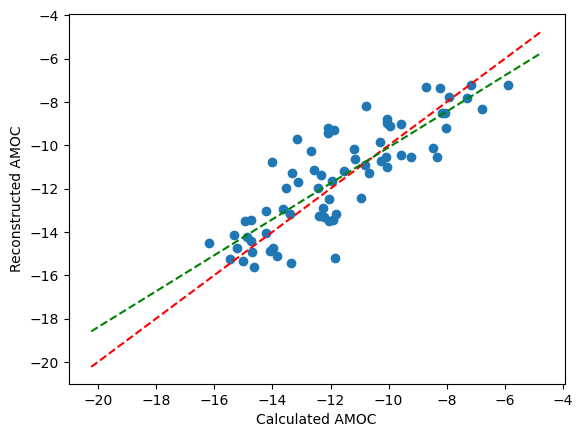

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(t_umo_obs.sel(time = test_predictions.time, method = "nearest").dv_dz_times_X.values, test_predictions.values)
# plt.scatter(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, t_merged_argo_2000.sel(time = transport.time, method = 'nearest').values)
plt.xlabel('Calculated AMOC')
plt.ylabel('Reconstructed AMOC')
min_transport = min(test_predictions.min(), t_umo_obs.dv_dz_times_X.min()).values[()]
max_transport = max(test_predictions.max(), t_umo_obs.dv_dz_times_X.max()).values[()]
plt.plot([min_transport, max_transport], [min_transport, max_transport], 'r--')

from sklearn.linear_model import LinearRegression

lr = LinearRegression().fit(t_umo_obs.sel(time = test_predictions.time, method = "nearest").dv_dz_times_X.values.reshape(-1, 1), test_predictions.values.reshape(-1, 1))
# in_X = np.linspace(-35, -5, 100).reshape(-1, 1)
# plt.plot(in_X, lr.predict(in_X), 'k--')
# lr = LinearRegression().fit(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values.reshape(-1, 1), t_merged_argo_2000.sel(time = transport.time, method = 'nearest').values.reshape(-1, 1))
in_X = np.linspace(min_transport, max_transport, 100).reshape(-1, 1)
plt.plot(in_X, lr.predict(in_X), 'g--')

plt.savefig(experiment_path / f'AMOC_reconstruction.png')

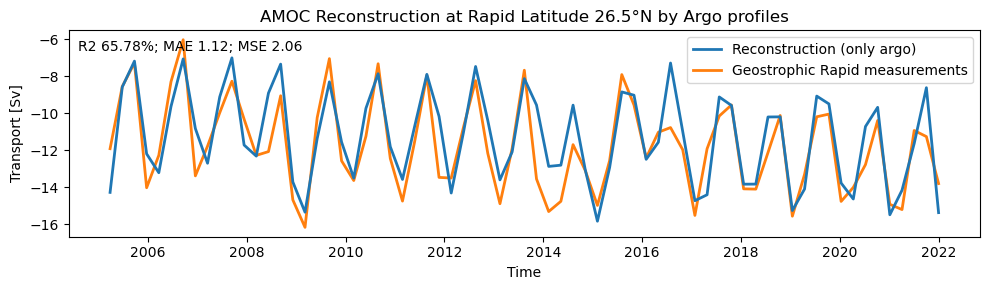

In [39]:
fig = plt.figure(figsize=(10, 3))
ax = fig.add_subplot(1,1,1)

# calc = t_merged_argo_2000.sel(time = transport.time, method = 'nearest')
# ax.plot(calc.time, calc.values, label = 'Geostrohphic calculation from Argos', alpha = .5, color = 'black')
rapid = t_umo_obs.sel(time = test_predictions.time, method = 'nearest')
ax.plot(test_predictions.time, test_predictions.values, label = 'Reconstruction (only argo)', linewidth = 2, zorder = 20)
ax.plot(rapid.time, rapid.dv_dz_times_X.values, label = 'Geostrophic Rapid measurements', linewidth = 2)

plt.legend()
ax.set_ylabel('Transport [Sv]')
ax.set_xlabel('Time')

plt.text(0.01, 0.9, f'R2 {r2_score(t_umo_obs.sel(time = test_predictions.time, method = "nearest").dv_dz_times_X.values, test_predictions.values)*100:.2f}%; MAE {mae_error:.2f}; MSE {mean_squared_error(t_umo_obs.sel(time = test_predictions.time, method = "nearest").dv_dz_times_X.values, test_predictions.values):.2f}', transform=ax.transAxes)
plt.title('AMOC Reconstruction at Rapid Latitude 26.5°N by Argo profiles')
fig.tight_layout()
plt.savefig(experiment_path / f'argo_nn_reconstruction.png')

In [ ]:
config_values = {
    'n_compartments': n_compartments,
    'n_embedding': n_embedding,
    'version': version,
    'distance_assignment_module': distance_assignment_module,
    'dataset_path': str(dataset_path),
    'target_reference_level': target_reference_level,
    'missing_values_in_target': missing_values_in_target,
    'using_missing_indices': using_missing_indices,
    'using_transport_from_previous_year': using_transport_from_previous_year,
    'add_tmp': add_tmp,
    'add_sal': add_sal,
    'random_split_data': random_split_data,
    'use_deep_dvdz': use_deep_dvdz,
    'mean_dv_dz_moorings': list(mean_dv_dz_moorings.values),
    'std_dv_dz_moorings': list(std_dv_dz_moorings.values),

}
import json
with open(experiment_path / f'config.json', 'w') as f:
    json.dump(config_values, f)

In [ ]:
# save best model 
torch.save(best_model.state_dict(), experiment_path / 'model.pt')

In [38]:
experiment_path

PosixPath('../rapid-geostrophic-reconstruction/figs/experiment_20241211_134909')